In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path(r"C:\Users\tmaci\Documents\Doutorado_Populismo")

dados = BASE / "dados" / "processados"

wvs = pd.read_parquet(
    dados / "wvs_vars_needed.parquet"
)

print(wvs.shape)
wvs.head()

(443488, 66)


,S002VS,S020,S003,COUNTRY_ALPHA,S018,G006,E012,G001,G002,G024,...,A168,A168A,G007_34_B,G007_35_B,G007_36_B,E069_01,E069_02,E069_06,E069_17,E033
0,3,1998,8,ALB,1.001001,2,1,3,4,-4,...,-4,-4,-4,-4,-4,1,3,3,3,2
1,3,1998,8,ALB,1.001001,2,1,3,4,-4,...,-4,-4,-4,-4,-4,2,3,3,3,8
2,3,1998,8,ALB,1.001001,2,-1,3,4,-4,...,-4,-4,-4,-4,-4,1,3,3,3,5
3,3,1998,8,ALB,1.001001,3,0,4,5,-4,...,-4,-4,-4,-4,-4,1,2,2,3,3
4,3,1998,8,ALB,1.001001,2,-1,2,3,-4,...,-4,-4,-4,-4,-4,1,3,3,3,4


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path(r"C:\Users\tmaci\Documents\Doutorado_Populismo")
dados = BASE / "dados" / "processados"

wvs = pd.read_parquet(dados / "wvs_tese.parquet")

print(wvs.shape)
wvs.head()

(39720, 66)


,S002VS,S020,S003,COUNTRY_ALPHA,S018,G006,E012,G001,G002,G024,...,A168,A168A,G007_34_B,G007_35_B,G007_36_B,E069_01,E069_02,E069_06,E069_17,E033
0,6,2013,32,ARG,0.970874,2.0,0.0,NaN,NaN,NaN,...,NaN,9.0,3.0,NaN,NaN,4.0,4.0,4.0,4.0,3.0
1,6,2013,32,ARG,0.970874,2.0,0.0,NaN,NaN,NaN,...,NaN,8.0,NaN,NaN,NaN,3.0,4.0,2.0,3.0,5.0
2,6,2013,32,ARG,0.970874,2.0,0.0,NaN,NaN,NaN,...,NaN,5.0,3.0,NaN,NaN,4.0,4.0,4.0,4.0,3.0
3,6,2013,32,ARG,0.970874,2.0,0.0,NaN,NaN,NaN,...,NaN,6.0,3.0,NaN,NaN,4.0,4.0,4.0,4.0,5.0
4,6,2013,32,ARG,0.970874,1.0,0.0,NaN,NaN,NaN,...,NaN,4.0,3.0,2.0,2.0,3.0,4.0,2.0,3.0,NaN


In [3]:
# ============================================================
# Filtrar onda 7, como no notebook original
# ============================================================

df_w7 = wvs[wvs["S002VS"] == 7].copy()

print(df_w7.shape)
print(df_w7[["COUNTRY_ALPHA", "S020", "S002VS"]].head())
print(df_w7["COUNTRY_ALPHA"].value_counts())

(24053, 66)
     COUNTRY_ALPHA  S020  S002VS
1030           ARG  2017       7
1031           ARG  2017       7
1032           ARG  2017       7
1033           ARG  2017       7
1034           ARG  2017       7
COUNTRY_ALPHA
CAN    4018
USA    2596
BOL    2067
BRA    1762
MEX    1741
COL    1520
PER    1400
GTM    1229
ECU    1200
NIC    1200
VEN    1190
PRI    1127
ARG    1003
CHL    1000
URY    1000
Name: count, dtype: int64


In [4]:
# ============================================================
# Funções auxiliares do Experimento 3
# ============================================================

missing_codes = [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10]

def clean_missing(s):
    return s.where(~s.isin(missing_codes), np.nan)

def binary_yes(s):
    x = clean_missing(s)
    return x.where(x.isin([0, 1]))

def scale_1to4_high_at_1(s):
    x = clean_missing(s)
    return (4 - x) / 3

def scale_1to4_high_at_4(s):
    x = clean_missing(s)
    return (x - 1) / 3

def scale_1to5_high_at_5(s):
    x = clean_missing(s)
    return (x - 1) / 4

def scale_1to10_high_at_10(s):
    x = clean_missing(s)
    return (x - 1) / 9

def political_action_123(s):
    x = clean_missing(s)
    return x.map({1: 1.0, 2: 0.5, 3: 0.0})

def mean_min_valid(data, cols, min_valid=1):
    sub = data[[c for c in cols if c in data.columns]]
    valid_count = sub.notna().sum(axis=1)
    return sub.mean(axis=1).where(valid_count >= min_valid)

def has_valid(col, data):
    if col not in data.columns:
        return False
    return clean_missing(data[col]).notna().sum() > 0

In [5]:
# ============================================================
# Construção dos indicadores — Experimento 3
# ============================================================

scores_w7 = pd.DataFrame(index=df_w7.index)

# 1. Grandiosidade nacional
scores_w7["national_pride"] = scale_1to4_high_at_1(df_w7["G006"])
scores_w7["willing_to_fight"] = binary_yes(df_w7["E012"])

scores_w7["grandiosity"] = mean_min_valid(
    scores_w7,
    ["national_pride", "willing_to_fight"],
    min_valid=1
)

# 2. Hostilidade a exogrupos
scores_w7["reject_different_race"] = binary_yes(df_w7["A124_02"])
scores_w7["reject_immigrants"] = binary_yes(df_w7["A124_06"])
scores_w7["reject_homosexuals"] = binary_yes(df_w7["A124_09"])
scores_w7["reject_other_religion"] = binary_yes(df_w7["A124_12"])

scores_w7["reject_different_language"] = (
    binary_yes(df_w7["A124_43"]) if has_valid("A124_43", df_w7) else np.nan
)

scores_w7["immigration_restriction"] = (
    clean_missing(df_w7["E143"]).map({1: 0.0, 2: 1/3, 3: 2/3, 4: 1.0})
    if has_valid("E143", df_w7) else np.nan
)

scores_w7["outgroup_hostility"] = mean_min_valid(
    scores_w7,
    [
        "reject_different_race",
        "reject_immigrants",
        "reject_homosexuals",
        "reject_other_religion",
        "reject_different_language",
        "immigration_restriction"
    ],
    min_valid=2
)

# 3. Autoritarismo
scores_w7["respect_authority"] = clean_missing(df_w7["E018"]).map({
    1: 1.0,
    2: 0.5,
    3: 0.0
})

scores_w7["strong_leader"] = scale_1to4_high_at_1(df_w7["E114"])
scores_w7["army_rule"] = scale_1to4_high_at_1(df_w7["E116"])

scores_w7["religious_law_no_parties"] = (
    scale_1to4_high_at_1(df_w7["E117B"]) if has_valid("E117B", df_w7) else np.nan
)

scores_w7["army_as_democracy"] = (
    scale_1to10_high_at_10(df_w7["E228"]) if has_valid("E228", df_w7) else np.nan
)

scores_w7["authoritarianism"] = mean_min_valid(
    scores_w7,
    [
        "respect_authority",
        "strong_leader",
        "army_rule",
        "religious_law_no_parties",
        "army_as_democracy"
    ],
    min_valid=2
)

# 4. Mobilização política
scores_w7["politics_important"] = scale_1to4_high_at_1(df_w7["A004"])
scores_w7["interest_politics"] = scale_1to4_high_at_1(df_w7["E023"])

scores_w7["discuss_politics"] = (
    clean_missing(df_w7["A062"]).map({1: 1.0, 2: 0.5, 3: 0.0})
    if has_valid("A062", df_w7) else np.nan
)

scores_w7["petition"] = political_action_123(df_w7["E025"])
scores_w7["boycott"] = political_action_123(df_w7["E026"])
scores_w7["demonstration"] = political_action_123(df_w7["E027"])

scores_w7["contact_official"] = (
    political_action_123(df_w7["E287"]) if has_valid("E287", df_w7) else np.nan
)

scores_w7["encourage_action"] = (
    political_action_123(df_w7["E288"]) if has_valid("E288", df_w7) else np.nan
)

scores_w7["political_mobilization"] = mean_min_valid(
    scores_w7,
    [
        "politics_important",
        "interest_politics",
        "discuss_politics",
        "petition",
        "boycott",
        "demonstration",
        "contact_official",
        "encourage_action"
    ],
    min_valid=3
)

# 5. Baixa confiança social
scores_w7["low_interpersonal_trust"] = clean_missing(df_w7["A165"]).map({
    1: 0.0,
    2: 1.0
})

scores_w7["distrust_first_time"] = (
    scale_1to4_high_at_4(df_w7["G007_34_B"]) if has_valid("G007_34_B", df_w7) else np.nan
)

scores_w7["distrust_other_religion"] = (
    scale_1to4_high_at_4(df_w7["G007_35_B"]) if has_valid("G007_35_B", df_w7) else np.nan
)

scores_w7["distrust_other_nationality"] = (
    scale_1to4_high_at_4(df_w7["G007_36_B"]) if has_valid("G007_36_B", df_w7) else np.nan
)

scores_w7["low_social_trust"] = mean_min_valid(
    scores_w7,
    [
        "low_interpersonal_trust",
        "distrust_first_time",
        "distrust_other_religion",
        "distrust_other_nationality"
    ],
    min_valid=1
)

# 6. Ressentimento institucional
scores_w7["low_human_rights_respect"] = scale_1to4_high_at_4(df_w7["E124"])

scores_w7["no_say_government"] = (
    scale_1to5_high_at_5(df_w7["E291"]) if has_valid("E291", df_w7) else np.nan
)

scores_w7["distrust_parliament"] = scale_1to4_high_at_4(df_w7["E069_07"])
scores_w7["distrust_government"] = scale_1to4_high_at_4(df_w7["E069_11"])
scores_w7["distrust_parties"] = scale_1to4_high_at_4(df_w7["E069_12"])

scores_w7["grievance"] = mean_min_valid(
    scores_w7,
    [
        "low_human_rights_respect",
        "no_say_government",
        "distrust_parliament",
        "distrust_government",
        "distrust_parties"
    ],
    min_valid=2
)

# 7. Confiança em autoridade estatal/moral
scores_w7["trust_churches"] = scale_1to4_high_at_1(df_w7["E069_01"])
scores_w7["trust_armed_forces"] = scale_1to4_high_at_1(df_w7["E069_02"])
scores_w7["trust_police"] = scale_1to4_high_at_1(df_w7["E069_06"])

scores_w7["trust_state_authority"] = mean_min_valid(
    scores_w7,
    [
        "trust_churches",
        "trust_armed_forces",
        "trust_police"
    ],
    min_valid=2
)

# Índices finais
scores_w7["collective_narcissism_proxy_w7"] = mean_min_valid(
    scores_w7,
    [
        "grandiosity",
        "outgroup_hostility",
        "authoritarianism",
        "political_mobilization",
        "low_social_trust",
        "grievance"
    ],
    min_valid=4
)

scores_w7["imagined_subcommunity_proxy_w7"] = mean_min_valid(
    scores_w7,
    [
        "outgroup_hostility",
        "authoritarianism",
        "political_mobilization",
        "low_social_trust",
        "grievance",
        "trust_state_authority"
    ],
    min_valid=4
)

print(scores_w7.shape)
scores_w7.head()

(24053, 42)


,national_pride,willing_to_fight,grandiosity,reject_different_race,reject_immigrants,reject_homosexuals,reject_other_religion,reject_different_language,immigration_restriction,outgroup_hostility,...,distrust_parliament,distrust_government,distrust_parties,grievance,trust_churches,trust_armed_forces,trust_police,trust_state_authority,collective_narcissism_proxy_w7,imagined_subcommunity_proxy_w7
1030,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.111111,...,1.000000,1.000000,1.000000,0.750000,0.000000,0.000000,1.000000,0.333333,0.524769,0.413657
1031,1.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.666667,0.111111,...,1.000000,0.666667,0.666667,0.650000,0.000000,0.000000,0.000000,0.000000,0.425463,0.342130
1032,1.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.666667,0.111111,...,1.000000,0.666667,1.000000,0.533333,1.000000,1.000000,0.333333,0.777778,0.458102,0.504398
1033,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.111111,...,1.000000,1.000000,1.000000,0.733333,0.666667,0.333333,1.000000,0.666667,0.508796,0.453241
1034,1.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.666667,0.111111,...,0.666667,0.333333,0.666667,0.479167,0.333333,0.666667,0.666667,0.555556,0.326157,0.335417


In [8]:
saida = BASE / "dados" / "processados" / "wvs_indicadores_w7.parquet"

scores_w7.to_parquet(saida, index=False)

print(saida)
print(saida.exists())# ============================================================
# Montar analysis_w7, como no notebook original
# ============================================================

analysis_w7 = pd.concat(
    [
        df_w7[["COUNTRY_ALPHA", "S020", "S002VS", "S018", "E033"]],
        scores_w7
    ],
    axis=1
)

analysis_w7["left_right"] = analysis_w7["E033"]

def ideological_group(x):
    if pd.isna(x):
        return np.nan
    elif x <= 3:
        return "left"
    elif x <= 7:
        return "center"
    else:
        return "right"

analysis_w7["ideological_group"] = analysis_w7["left_right"].apply(ideological_group)

print(analysis_w7.shape)

C:\Users\tmaci\Documents\Doutorado_Populismo\dados\processados\wvs_indicadores_w7.parquet
True
(24053, 49)


In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imp = pd.DataFrame(
    imputer.fit_transform(analysis_w7[efa_vars]),
    columns=efa_vars,
    index=analysis_w7.index
)

print(X_imp.shape)

NameError: name 'efa_vars' is not defined

In [10]:
efa_vars = [

    # Grandiosidade nacional
    "national_pride",
    "willing_to_fight",

    # Hostilidade a exogrupos
    "reject_different_race",
    "reject_immigrants",
    "reject_homosexuals",
    "reject_other_religion",
    "reject_different_language",
    "immigration_restriction",

    # Autoritarismo
    "respect_authority",
    "strong_leader",
    "army_rule",
    "religious_law_no_parties",
    "army_as_democracy",

    # Mobilização política
    "politics_important",
    "interest_politics",
    "discuss_politics",
    "petition",
    "boycott",
    "demonstration",
    "contact_official",
    "encourage_action",

    # Confiança social
    "low_interpersonal_trust",
    "distrust_first_time",
    "distrust_other_religion",
    "distrust_other_nationality",

    # Ressentimento institucional
    "low_human_rights_respect",
    "no_say_government",
    "distrust_parliament",
    "distrust_government",
    "distrust_parties",

    # Autoridade moral/estatal
    "trust_churches",
    "trust_armed_forces",
    "trust_police"
]

print(f"{len(efa_vars)} variáveis para a AFE.")

33 variáveis para a AFE.


In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imp = pd.DataFrame(
    imputer.fit_transform(analysis_w7[efa_vars]),
    columns=efa_vars,
    index=analysis_w7.index
)

print(X_imp.shape)

(24053, 33)


In [12]:
!pip install factor_analyzer -q

In [13]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from factor_analyzer import FactorAnalyzer

print("factor_analyzer carregado.")

factor_analyzer carregado.


In [15]:
kmo_per_item, kmo_total = calculate_kmo(X_imp)
chi2, p = calculate_bartlett_sphericity(X_imp)

print("KMO geral:", round(kmo_total, 3))
print("Bartlett chi2:", round(chi2, 2))
print("p:", p)

KMO geral: 0.863
Bartlett chi2: 199584.18
p: 0.0


C:\Users\tmaci\anaconda3\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


,Fator,Autovalor observado,Autovalor aleatório médio,Reter
0,1,5.546,1.071,True
1,2,2.998,1.062,True
2,3,2.506,1.056,True
3,4,1.667,1.051,True
4,5,1.448,1.046,True
5,6,1.233,1.042,True
6,7,1.122,1.037,True
7,8,1.103,1.033,True
8,9,0.935,1.029,False
9,10,0.924,1.025,False


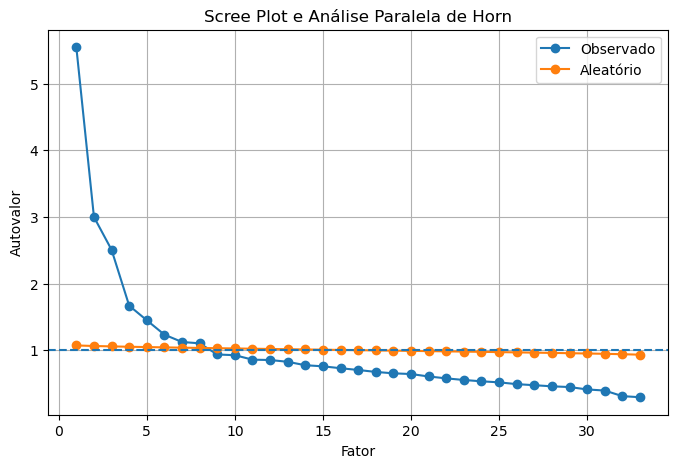

In [16]:
# ============================================================
# SCREE PLOT + ANÁLISE PARALELA DE HORN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = X_imp.copy()

X_std = StandardScaler().fit_transform(X)

pca_real = PCA()
pca_real.fit(X_std)

autovalores_observados = pca_real.explained_variance_

n_iter = 500
random_eigens = np.zeros((n_iter, X_std.shape[1]))

for i in range(n_iter):
    random_data = np.random.normal(size=X_std.shape)
    pca_rand = PCA()
    pca_rand.fit(random_data)
    random_eigens[i, :] = pca_rand.explained_variance_

autovalores_aleatorios = random_eigens.mean(axis=0)

parallel_table = pd.DataFrame({
    "Fator": range(1, len(autovalores_observados) + 1),
    "Autovalor observado": autovalores_observados,
    "Autovalor aleatório médio": autovalores_aleatorios,
    "Reter": autovalores_observados > autovalores_aleatorios
})

display(parallel_table.head(15).round(3))

plt.figure(figsize=(8, 5))
plt.plot(parallel_table["Fator"], parallel_table["Autovalor observado"], marker="o", label="Observado")
plt.plot(parallel_table["Fator"], parallel_table["Autovalor aleatório médio"], marker="o", label="Aleatório")
plt.axhline(y=1, linestyle="--")
plt.xlabel("Fator")
plt.ylabel("Autovalor")
plt.title("Scree Plot e Análise Paralela de Horn")
plt.legend()
plt.grid(True)
plt.show()

parallel_table.to_csv(
    BASE / "resultados" / "analise_paralela_horn.csv",
    index=False
)

In [17]:
# ============================================================
# EXPERIMENTO 3 — AFE FINAL DE 8 FATORES
# ============================================================

fa8 = FactorAnalyzer(
    n_factors=8,
    rotation="oblimin",
    method="minres"
)

fa8.fit(X_imp)

nomes_fatores8 = [
    "efa8_institutional_alienation",
    "efa8_political_action",
    "efa8_outgroup_hostility",
    "efa8_social_outgroup_distrust",
    "efa8_moral_political_authoritarianism",
    "efa8_political_interest",
    "efa8_coercive_institutional_trust",
    "efa8_symbolic_nationalism"
]

loadings8 = pd.DataFrame(
    fa8.loadings_,
    index=X_imp.columns,
    columns=nomes_fatores8
)

scores8 = fa8.transform(X_imp)

scores8_df = pd.DataFrame(
    scores8,
    index=analysis_w7.index,
    columns=nomes_fatores8
)

analysis_efa8 = analysis_w7.join(scores8_df)

variance8 = pd.DataFrame(
    fa8.get_factor_variance(),
    index=["SS Loadings", "Proportion Var", "Cumulative Var"],
    columns=nomes_fatores8
)

display(loadings8.round(3))
display(variance8.round(3))

C:\Users\tmaci\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\tmaci\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,efa8_institutional_alienation,efa8_political_action,efa8_outgroup_hostility,efa8_social_outgroup_distrust,efa8_moral_political_authoritarianism,efa8_political_interest,efa8_coercive_institutional_trust,efa8_symbolic_nationalism
national_pride,-0.053,0.014,-0.001,-0.034,-0.028,-0.061,-0.006,0.523
willing_to_fight,0.084,0.013,0.091,0.013,0.104,0.109,0.082,0.357
reject_different_race,0.006,0.746,-0.031,-0.011,0.009,-0.006,-0.014,-0.006
reject_immigrants,0.021,0.657,0.025,-0.000,0.004,-0.016,0.023,0.005
reject_homosexuals,0.023,0.362,0.059,-0.038,0.031,0.103,-0.044,0.079
reject_other_religion,-0.016,0.682,0.006,0.015,-0.020,0.009,-0.022,0.003
reject_different_language,-0.007,0.638,0.011,0.007,-0.003,-0.003,0.028,-0.013
immigration_restriction,0.040,0.061,0.206,-0.042,-0.040,0.017,0.101,0.072
respect_authority,0.031,-0.012,0.086,-0.105,-0.042,0.072,0.162,0.324
strong_leader,0.030,0.008,0.026,-0.031,-0.029,0.475,-0.071,0.142


,efa8_institutional_alienation,efa8_political_action,efa8_outgroup_hostility,efa8_social_outgroup_distrust,efa8_moral_political_authoritarianism,efa8_political_interest,efa8_coercive_institutional_trust,efa8_symbolic_nationalism
SS Loadings,2.014,2.004,1.919,1.786,1.389,1.305,1.054,0.737
Proportion Var,0.061,0.061,0.058,0.054,0.042,0.040,0.032,0.022
Cumulative Var,0.061,0.122,0.180,0.234,0.276,0.316,0.348,0.370


In [18]:
# ============================================================
# EXPERIMENTO 3 — FATORES DE SEGUNDA ORDEM
# ============================================================

fatores = nomes_fatores8

X_second = analysis_efa8[fatores].dropna()

fa_second = FactorAnalyzer(
    n_factors=3,
    rotation="oblimin",
    method="minres"
)

fa_second.fit(X_second)

second_loadings = pd.DataFrame(
    fa_second.loadings_,
    index=fatores,
    columns=[
        "SOF1",
        "SOF2",
        "SOF3"
    ]
)

second_scores = fa_second.transform(X_second)

second_scores_df = pd.DataFrame(
    second_scores,
    index=X_second.index,
    columns=[
        "sof1_authoritarian_order_integration",
        "sof2_authoritarian_exclusion",
        "sof3_political_engagement"
    ]
)

analysis_second = analysis_efa8.join(second_scores_df)

display(second_loadings.round(3))
analysis_second.head()

C:\Users\tmaci\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\tmaci\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,SOF1,SOF2,SOF3
efa8_institutional_alienation,0.706,-0.181,-0.096
efa8_political_action,0.097,0.140,0.318
efa8_outgroup_hostility,0.464,-0.079,0.532
efa8_social_outgroup_distrust,0.048,0.645,-0.345
efa8_moral_political_authoritarianism,-0.062,0.871,0.082
efa8_political_interest,-0.079,-0.135,0.564
efa8_coercive_institutional_trust,-0.816,-0.059,-0.017
efa8_symbolic_nationalism,-0.249,-0.072,0.503


,COUNTRY_ALPHA,S020,S002VS,S018,E033,national_pride,willing_to_fight,grandiosity,reject_different_race,reject_immigrants,...,efa8_political_action,efa8_outgroup_hostility,efa8_social_outgroup_distrust,efa8_moral_political_authoritarianism,efa8_political_interest,efa8_coercive_institutional_trust,efa8_symbolic_nationalism,sof1_authoritarian_order_integration,sof2_authoritarian_exclusion,sof3_political_engagement
1030,ARG,2017,7,0.997009,5.0,1.0,1.0,1.0,0.0,0.0,...,-0.492103,-0.535936,0.902108,-1.084125,-1.282782,-0.199980,0.480398,0.458803,-0.324998,-1.154615
1031,ARG,2017,7,0.997009,NaN,1.0,0.0,0.5,0.0,0.0,...,-0.417502,-0.214594,1.092693,0.100003,-1.021864,-1.589763,-0.497288,1.148716,0.562466,-1.149978
1032,ARG,2017,7,0.997009,8.0,1.0,0.0,0.5,0.0,0.0,...,-0.453429,-0.039959,1.064496,0.569578,-1.211807,0.520844,0.381148,-0.054325,0.755208,-0.754373
1033,ARG,2017,7,0.997009,5.0,1.0,1.0,1.0,0.0,0.0,...,-0.382268,-0.911728,0.805517,1.526403,-1.251189,0.017916,0.148829,0.013801,1.279460,-1.001872
1034,ARG,2017,7,0.997009,NaN,1.0,0.0,0.5,0.0,0.0,...,-0.456399,-0.543081,-1.133260,-0.499333,-1.075221,0.559327,0.199433,-0.649466,-0.721972,-0.120746


In [19]:
# ============================================================
# EXPORTAÇÃO DOS RESULTADOS DO EXPERIMENTO 3
# ============================================================

resultados = BASE / "resultados"
processados = BASE / "dados" / "processados"

loadings8.to_csv(
    resultados / "afe8_loadings.csv",
    index=True
)

variance8.to_csv(
    resultados / "afe8_variancia.csv",
    index=True
)

second_loadings.to_csv(
    resultados / "afe_second_order_loadings.csv",
    index=True
)

analysis_efa8.to_parquet(
    processados / "afe8_scores.parquet",
    index=True
)

analysis_second.to_parquet(
    processados / "afe_second_order_scores.parquet",
    index=True
)

print("Experimento 3 concluído.")
print("Arquivos salvos em:")
print(processados / "afe8_scores.parquet")
print(processados / "afe_second_order_scores.parquet")
print(resultados / "afe8_loadings.csv")
print(resultados / "afe_second_order_loadings.csv")

Experimento 3 concluído.
Arquivos salvos em:
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\processados\afe8_scores.parquet
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\processados\afe_second_order_scores.parquet
C:\Users\tmaci\Documents\Doutorado_Populismo\resultados\afe8_loadings.csv
C:\Users\tmaci\Documents\Doutorado_Populismo\resultados\afe_second_order_loadings.csv


C:\Users\tmaci\05_experimento4_AFM.ipynb
C:\Users\tmaci\experimento3.ipynb
C:\Users\tmaci\Untitled.ipynb
C:\Users\tmaci\Untitled1.ipynb
C:\Users\tmaci\Untitled2.ipynb
